# 05 SHAP Explainability


In [1]:
from pathlib import Path
import sys
sys.path.append(str(Path('..')/'src'))


## Objectives

- Produce **global explanations** (which features matter overall).
- Produce **local explanations** (why a specific course is scored high/low).
- Save plots for your research paper.

We explain the **profitability model** trained in `03_train_multiple_models.ipynb`.


In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import joblib

import shap
import matplotlib.pyplot as plt

train_df = pd.read_parquet(Path('..')/'data'/'processed'/'train.parquet')
test_df  = pd.read_parquet(Path('..')/'data'/'processed'/'test.parquet')

bundle = joblib.load(Path('..')/'models'/'profit_model.joblib')
pipe = bundle['pipeline']
num_cols = bundle['numeric_cols']
cat_cols = bundle['categorical_cols']

X_train = train_df[num_cols + cat_cols]
y_train = train_df['log_profit']
X_test  = test_df[num_cols + cat_cols]
y_test  = test_df['log_profit']

pipe


c:\Python\Projects\Course Recommendation system\course_recommendation_research\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sp

### Build SHAP explainer

We explain the **model** after preprocessing:
- Transform `X` with the pipeline's preprocessor
- Use a SHAP explainer appropriate for the estimator

This is robust for both linear and tree/boosting models.


In [3]:
pre = pipe.named_steps['pre']
model = pipe.named_steps['model']

X_train_t = pre.transform(X_train)
X_test_t  = pre.transform(X_test)

# Feature names after one-hot encoding
try:
    feature_names = pre.get_feature_names_out()
except Exception:
    feature_names = None

# Use a small background set for speed
bg = X_train_t[:200]

# SHAP explainer selection
model_name = bundle['model_name']

if model_name == 'ridge':
    explainer = shap.LinearExplainer(model, bg, feature_names=feature_names)
else:
    explainer = shap.TreeExplainer(model, data=bg, feature_names=feature_names)

shap_values = explainer(X_test_t[:500])  # sample for speed
shap_values


.values =
array([[-8.07327560e-02, -3.03645863e+00,  1.04134707e-04, ...,
         0.00000000e+00,  8.22737090e-05,  0.00000000e+00],
       [ 1.49677268e+00, -2.47190025e+00,  1.60415055e-03, ...,
         0.00000000e+00,  2.90912161e-05,  0.00000000e+00],
       [ 4.84446586e-01,  7.62184225e-01,  5.30414967e-04, ...,
         0.00000000e+00,  1.08682313e-04,  0.00000000e+00],
       ...,
       [-1.05652454e+01,  1.53710252e+00,  4.25434660e-04, ...,
         0.00000000e+00, -8.72314398e-04,  0.00000000e+00],
       [-9.93203361e+00,  9.09498208e-01, -4.30195360e-03, ...,
         0.00000000e+00, -6.86523786e-04,  0.00000000e+00],
       [ 2.01342862e+00, -1.23333904e-02,  5.98363500e-04, ...,
         0.00000000e+00,  4.59447547e-05,  0.00000000e+00]],
      shape=(500, 20))

.base_values =
array([9.02521581, 9.02521581, 9.02521581, 9.02521581, 9.02521581,
       9.02521581, 9.02521581, 9.02521581, 9.02521581, 9.02521581,
       9.02521581, 9.02521581, 9.02521581, 9.02521581, 9.025

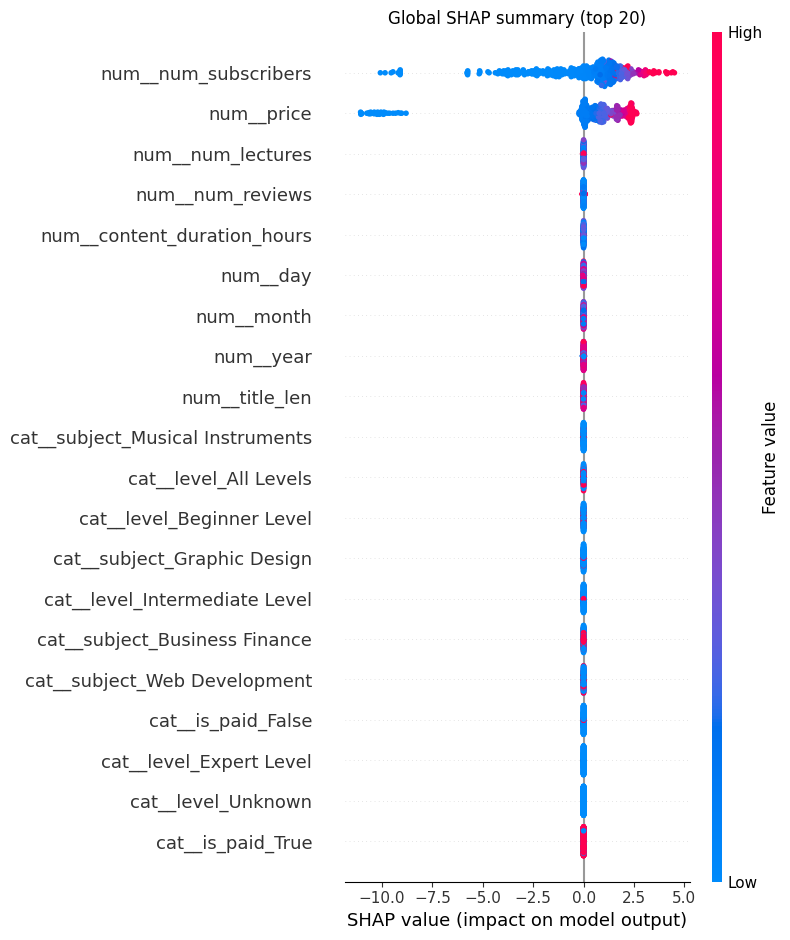

In [4]:
# Global importance (summary plot)
plt.figure()
shap.summary_plot(shap_values, feature_names=feature_names, show=False, max_display=20)
plt.title('Global SHAP summary (top 20)')
plt.tight_layout()
plt.show()


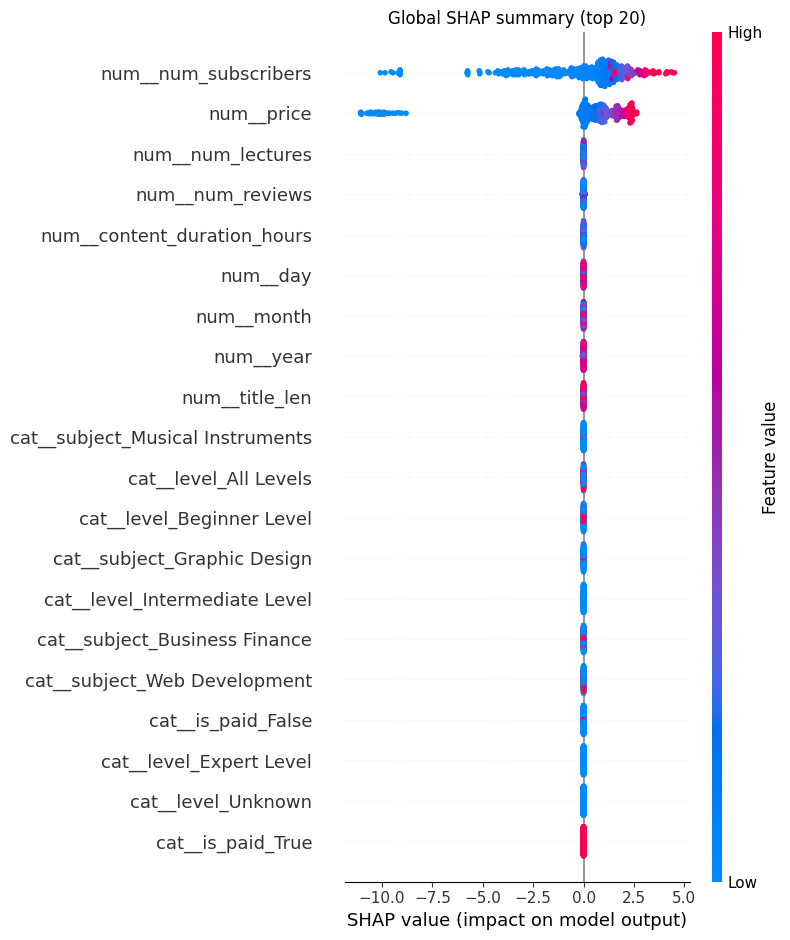

WindowsPath('../reports/figures/shap_summary_top20.png')

In [5]:
# Save figure for paper
fig_dir = Path('..')/'reports'/'figures'
fig_dir.mkdir(parents=True, exist_ok=True)

plt.figure()
shap.summary_plot(shap_values, feature_names=feature_names, show=False, max_display=20)
plt.title('Global SHAP summary (top 20)')
plt.tight_layout()
plt.savefig(fig_dir/'shap_summary_top20.png', dpi=200)
plt.show()

fig_dir/'shap_summary_top20.png'


### Local explanation (single course)

Pick one test example and visualize a waterfall plot.


In [6]:
i = 0
x_row = X_test.iloc[[i]]
row_meta = test_df.iloc[i][['course_id','course_title','subject','price','num_subscribers','profit']]
row_meta


course_id                               608436
course_title       Présentation du Banjo Ténor
subject                    Musical Instruments
price                                       20
num_subscribers                             18
profit                                     360
Name: 0, dtype: object

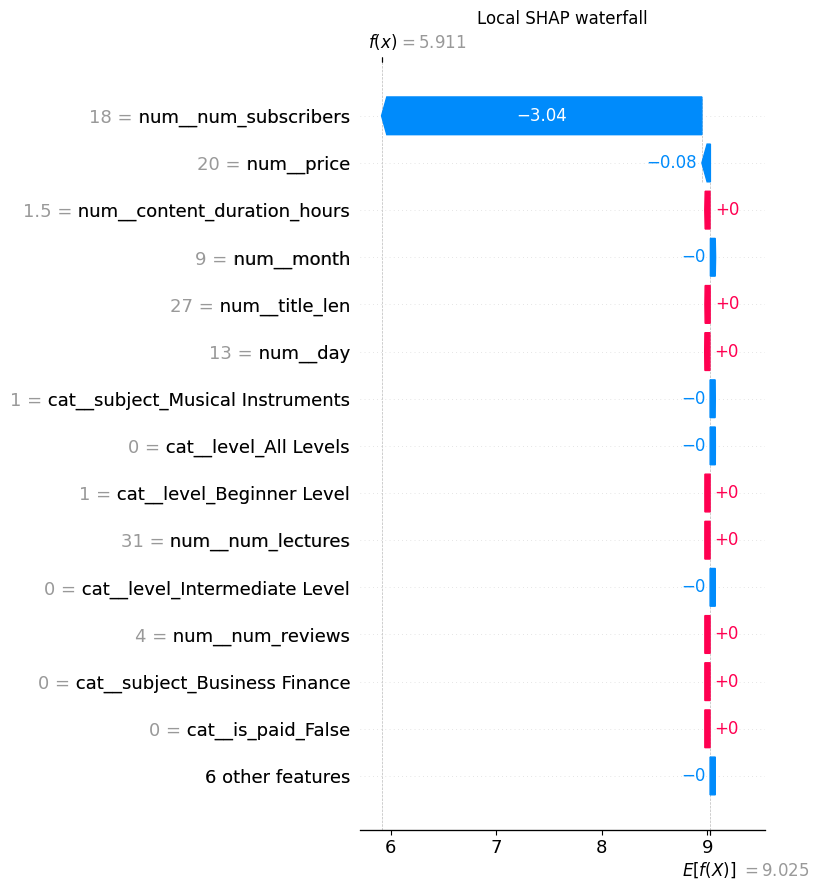

In [7]:
x_row_t = pre.transform(x_row)
sv_row = explainer(x_row_t)

plt.figure()
shap.plots.waterfall(sv_row[0], max_display=15, show=False)
plt.title('Local SHAP waterfall')
plt.tight_layout()
plt.show()


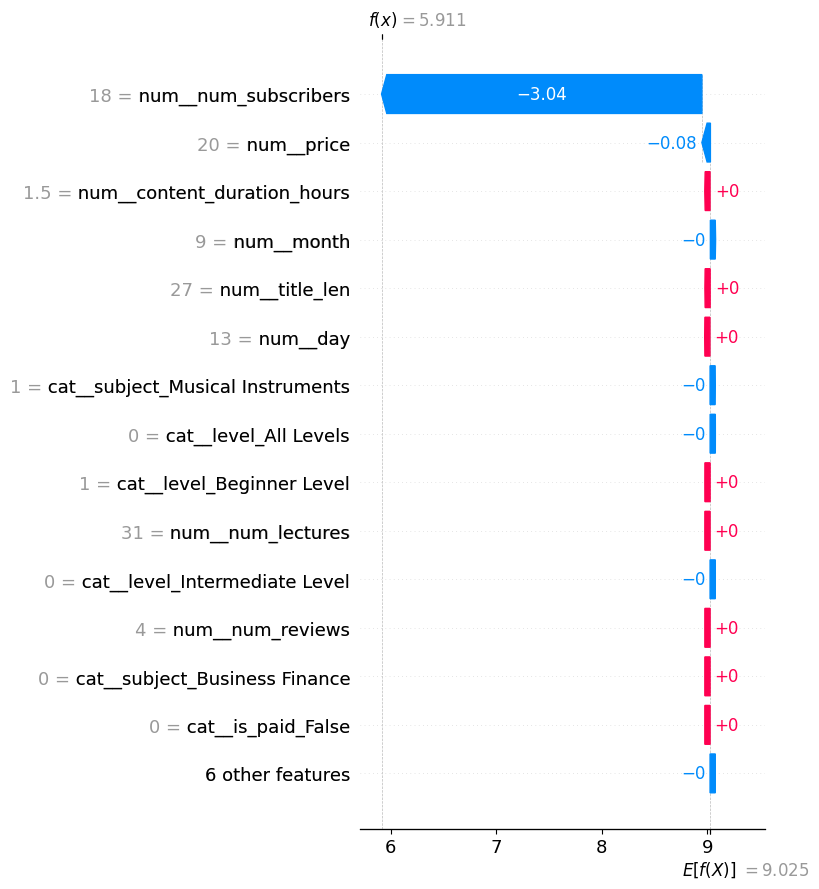

WindowsPath('../reports/figures/shap_local_waterfall_example.png')

In [8]:
# Save local plot
plt.figure()
shap.plots.waterfall(sv_row[0], max_display=15, show=False)
plt.tight_layout()
plt.savefig(fig_dir/'shap_local_waterfall_example.png', dpi=200)
plt.show()

fig_dir/'shap_local_waterfall_example.png'
